1、句子的向量化

举例：

In [1]:
from langchain_ollama import OllamaEmbeddings
import os
import dotenv

dotenv.load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

embedding_model = OllamaEmbeddings(
    # model="nomic-embed-text"
    model = "nomic-embed-text"
)

text = "Nice to meet you!"

embed_query = embedding_model.embed_query(text = text,)

print(len(embed_query))  # 1536 --> 3072

print(embed_query[:10])

128
[0.23137255012989044, 0.6039215922355652, 0.08627451211214066, 0.9450980424880981, 0.6117647290229797, 0.007843137718737125, 0.1411764770746231, 0.07450980693101883, 0.29411765933036804, 0.46666666865348816]


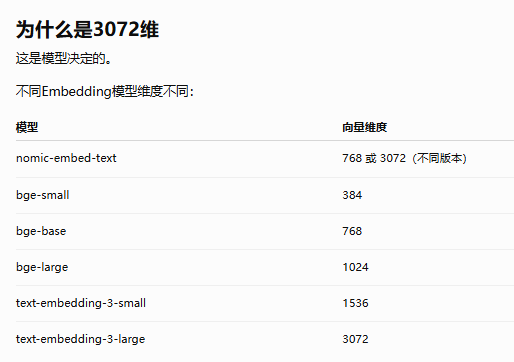

2、文档的向量化

文档的向量化，接收的参数是字符串数组。

举例1：


In [2]:
from langchain_ollama import OllamaEmbeddings
import numpy as np
import os
import dotenv

dotenv.load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

# 初始化嵌入模型
embeddings_model = OllamaEmbeddings(model="nomic-embed-text")

# 待嵌入的文本列表
texts = [
    "Hi there!",
    "Oh, hello!",
    "What's your name?",
    "My friends call me World",
    "Hello World!"
]

# 生成嵌入向量
embeddings = embeddings_model.embed_documents(texts)


for i in range(len(texts)):
    print(f"{texts[i]}:{embeddings[i][:3]}",end="\n\n")


Hi there!:[0.364705890417099, 0.6980392336845398, 0.4901960790157318]

Oh, hello!:[0.7568627595901489, 0.16470588743686676, 0.15294118225574493]

What's your name?:[0.843137264251709, 0.8470588326454163, 0.0784313753247261]

My friends call me World:[0.6627451181411743, 0.18039216101169586, 0.5372549295425415]

Hello World!:[0.13333334028720856, 0.7568627595901489, 0.5411764979362488]



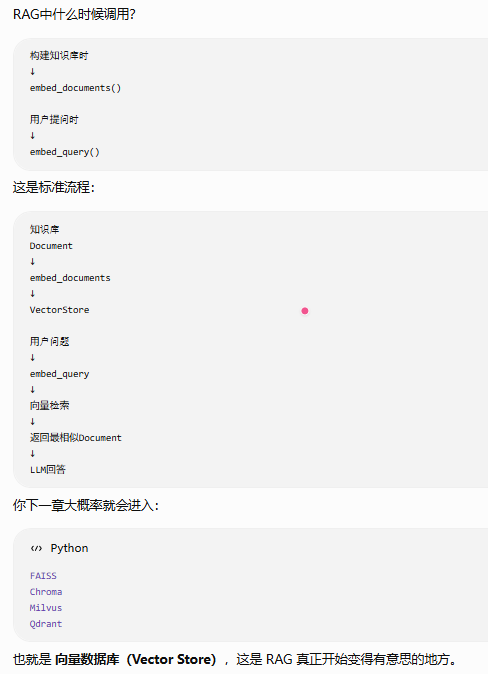

举例2：


In [3]:
from dotenv import load_dotenv
from langchain_community.document_loaders import CSVLoader
from langchain_ollama import OllamaEmbeddings


embeddings_model = OllamaEmbeddings(
    model="nomic-embed-text",
)

# 情况1：
loader = CSVLoader("./asset/load/03-load.csv", encoding="utf-8")
docs = loader.load_and_split()

#print(len(docs))

# 存放的是每一个chrunk的embedding。
embeded_docs = embeddings_model.embed_documents([doc.page_content for doc in docs])
print(len(embeded_docs))
# 表示的是每一个chrunk的embedding的维度
print(len(embeded_docs[0]))
print(embeded_docs[0][:10])

4
128
[0.6509804129600525, 0.08235294371843338, 0.6745098233222961, 0.5686274766921997, 0.45490196347236633, 0.6627451181411743, 0.3137255012989044, 0.3529411852359772, 0.6196078658103943, 0.529411792755127]
